# Nuclear LCOE & NPV: ITC vs. PTC (§45Y, §45J) Incentive Comparison

Standalone notebook with just the LCOE breakdown and NPV plots comparing
incentive scenarios (no incentive, the §48E ITC, the §45Y-style PTC, and the
§45J advanced nuclear PTC, capped per §45J(c)(1)) for 1 and 2 AP1000-class
units of the nuclear + data center Case 1 model.


In [1]:
import sys
sys.path.insert(0, "/Users/svijaysh/NPP+DCfork/H2Integrate")

import copy
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from h2integrate.core.h2integrate_model import H2IntegrateModel
from h2integrate.core.file_utils import get_path
from h2integrate.finances.profast_base import ProFastBase

# Resolve robustly regardless of the notebook's cwd (matches how
# H2IntegrateModel resolves config paths internally).
EXAMPLE_DIR = get_path("examples/32_nuclear_DC_case_1")

with open(EXAMPLE_DIR / "plant_config.yaml") as f:
    base_plant_config = yaml.safe_load(f)

ITC_FRACTION = 0.30


def make_h2i(plant_config_dict):
    config = {
        "name": "nuclear_datacenter_config",
        "system_summary": "Nuclear plant powering a data center",
        "driver_config": str(EXAMPLE_DIR / "driver_config.yaml"),
        "technology_config": str(EXAMPLE_DIR / "tech_config.yaml"),
        "plant_config": plant_config_dict,
    }
    model = H2IntegrateModel(config)
    model.setup()
    return model


def run_at_capacity(model, capacity_kw):
    model.prob.set_val("nuclear.system_capacity", capacity_kw, units="kW")
    model.prob.set_val("grid.interconnection_size", capacity_kw, units="kW")
    # nuclear_poi is the cost-only interconnection technology (see
    # tech_config.yaml) that adds nuclear's own POI CapEx/OpEx to the LCOE
    # without pulling in grid buy/sell revenue -- keep it sized to match.
    model.prob.set_val("nuclear_poi.interconnection_size", capacity_kw, units="kW")
    model.prob.set_val(
        "nuclear.electricity_command_value", np.full(8760, capacity_kw), units="kW"
    )
    # Check if this is ok , why is 500,000
    model.prob.set_val(
        "grid.electricity_command_value", np.full(8760, 500_000), units="kW"
    )
    model.run()


def set_itc(plant_config_dict, value_usd):
    """Apply an ITC value to the LCOE finance-group config only."""
    pc = copy.deepcopy(plant_config_dict)
    pc["finance_parameters"]["finance_groups"]["model_inputs"]["params"][
        "one_time_cap_inct"
    ]["value"] = float(value_usd)
    return pc


def set_itc_all(plant_config_dict, value_usd):
    """Apply the same ITC value to both the LCOE and NPV finance-group configs."""
    pc = set_itc(plant_config_dict, value_usd)
    pc["finance_parameters"]["finance_groups"]["npv"]["model_inputs"]["params"][
        "one_time_cap_inct"
    ]["value"] = float(value_usd)
    return pc


def shortify(breakdown):
    """LCOE_breakdown dict -> {short category name: $/MWh}.

    `nuclear_poi`'s CapEx/OpEx/Feedstock (nuclear's own point-of-
    interconnection cost, included in the LCOE finance subgroup separately
    from `grid` so grid sell revenue isn't pulled in -- see plant_config.yaml)
    are merged into the corresponding `nuclear` category so downstream
    plotting code doesn't need its own category for it.
    """
    out = {}
    for k, v in breakdown.items():
        # Strip "LCOE: " prefix and any trailing "(...)" units, e.g.
        # "($/kWh)" or "($/kW/h)" -- ProFAST's unit string formatting varies.
        short = re.sub(r"\s*\([^)]*\)\s*$", "", k.replace("LCOE: ", "")).strip()
        out[short] = v * 1000  # $/kWh -> $/MWh
    for cat in ("CapEx", "OpEx", "Feedstock"):
        poi_key = f"nuclear_poi {cat}"
        if poi_key in out:
            out[f"nuclear {cat}"] = out.get(f"nuclear {cat}", 0.0) + out.pop(poi_key)
    return out


# -- Monkeypatch: let ProFAST apply a per-kWh production tax credit ------------
# H2Integrate has no config path for ProFAST's `add_incentive` (a per-unit-
# commodity incentive), so we patch it in here. Components without a
# `_ptc_config` attribute behave exactly as before (no-op).
if not hasattr(ProFastBase, "_orig_populate_profast"):
    ProFastBase._orig_populate_profast = ProFastBase.populate_profast

    def _populate_profast_with_ptc(self, inputs):
        pf = ProFastBase._orig_populate_profast(self, inputs)
        ptc = getattr(self, "_ptc_config", None)
        if ptc is not None:
            pf.add_incentive(
                name="PTC_nuclear",
                value=ptc["value_per_kwh"],
                decay=0.0,
                sunset_years=ptc["sunset_years"],
                tax_credit=True,
            )
        return pf

    ProFastBase.populate_profast = _populate_profast_with_ptc


def get_lco_component(model):
    for subsys in model.model.system_iter(include_self=True, recurse=True):
        if type(subsys).__name__ == "ProFastLCO":
            return subsys
    raise RuntimeError("ProFastLCO component not found in model tree")


def get_npv_component(model):
    for subsys in model.model.system_iter(include_self=True, recurse=True):
        if type(subsys).__name__ == "ProFastNPV":
            return subsys
    raise RuntimeError("ProFastNPV component not found in model tree")


# §45Y-style PTC: $0.015/kWh (1.5c), 10 years, flat (no decay, no phase-out)
PTC_45Y_CONFIG = {"value_per_kwh": 0.015, "sunset_years": 10}


def get_45j_config(capacity_kw, capacity_factor=1.0, sunset_years=8):
    """§45J(c)(1): the annual credit is capped at $125,000,000 per 1,000 MW of
    allocated national megawatt capacity. At capacity factors above ~79%, this
    cap binds and pulls the effective $/kWh rate below the nominal $0.018/kWh
    -- which is the case for this plant at its assumed ~100% capacity factor.
    Returns the properly capped effective rate for this specific capacity."""
    capacity_mw = capacity_kw / 1000
    annual_cap_usd = 125_000_000 * (capacity_mw / 1000)
    annual_production_kwh = capacity_kw * 8760 * capacity_factor
    nominal_rate = 0.018
    capped_rate = annual_cap_usd / annual_production_kwh
    return {"value_per_kwh": min(nominal_rate, capped_rate), "sunset_years": sunset_years}


## LCOE Breakdown: No Incentive vs. ITC vs. §45Y PTC vs. §45J PTC

Same cost-category breakdown as the ITC comparison above (CapEx, Feedstock,
Taxes, Finances), extended to four panels -- no incentive, ITC, the §45Y-style
PTC, and the §45J advanced nuclear PTC -- across the 1-unit/2-unit AP1000
sweep. Reuses `make_h2i`, `set_itc`, `run_at_capacity`, `get_lco_component`,
`PTC_45Y_CONFIG`, and `PTC_45J_CONFIG` from the cells above.


In [2]:
UNIT_MW_3WAY = 1200  # AP1000-class unit
capacity_sweep_mw = [UNIT_MW_3WAY * 1, UNIT_MW_3WAY * 2]  # 1 unit, 2 units

breakdown_rows_3way = []
for capacity_mw in capacity_sweep_mw:
    capacity_kw = capacity_mw * 1000

    # No incentive -- also gives us CapEx to size the ITC credit
    m_base = make_h2i(set_itc(base_plant_config, 0.0))
    run_at_capacity(m_base, capacity_kw)
    capex_usd = float(m_base.prob.get_val("nuclear.CapEx", units="USD")[0])
    breakdown_no_incentive = m_base.prob.get_val("finance_subgroup_nuclear.LCOE_breakdown")

    # ITC, sized to this capacity's own CapEx
    itc_usd = ITC_FRACTION * capex_usd
    m_itc = make_h2i(set_itc(base_plant_config, itc_usd))
    run_at_capacity(m_itc, capacity_kw)
    breakdown_itc = m_itc.prob.get_val("finance_subgroup_nuclear.LCOE_breakdown")

    # §45Y PTC -- same monkeypatched mechanism as the incentive-comparison cells above
    m_45y = make_h2i(set_itc(base_plant_config, 0.0))
    get_lco_component(m_45y)._ptc_config = PTC_45Y_CONFIG
    run_at_capacity(m_45y, capacity_kw)
    breakdown_45y = m_45y.prob.get_val("finance_subgroup_nuclear.LCOE_breakdown")

    # §45J PTC -- capped rate depends on this capacity (see get_45j_config in ptc_sweep)
    m_45j = make_h2i(set_itc(base_plant_config, 0.0))
    get_lco_component(m_45j)._ptc_config = get_45j_config(capacity_kw)
    run_at_capacity(m_45j, capacity_kw)
    breakdown_45j = m_45j.prob.get_val("finance_subgroup_nuclear.LCOE_breakdown")

    breakdown_rows_3way.append(
        {
            "nuclear_mw": capacity_mw,
            "breakdown_no_incentive": breakdown_no_incentive,
            "breakdown_itc": breakdown_itc,
            "breakdown_45y": breakdown_45y,
            "breakdown_45j": breakdown_45j,
        }
    )

df_no_incentive = pd.DataFrame(
    [{"nuclear_mw": r["nuclear_mw"], **shortify(r["breakdown_no_incentive"])} for r in breakdown_rows_3way]
).set_index("nuclear_mw")
df_itc_breakdown = pd.DataFrame(
    [{"nuclear_mw": r["nuclear_mw"], **shortify(r["breakdown_itc"])} for r in breakdown_rows_3way]
).set_index("nuclear_mw")
df_45y_breakdown = pd.DataFrame(
    [{"nuclear_mw": r["nuclear_mw"], **shortify(r["breakdown_45y"])} for r in breakdown_rows_3way]
).set_index("nuclear_mw")
df_45j_breakdown = pd.DataFrame(
    [{"nuclear_mw": r["nuclear_mw"], **shortify(r["breakdown_45j"])} for r in breakdown_rows_3way]
).set_index("nuclear_mw")

for label, df in (
    ("No incentive", df_no_incentive),
    ("ITC", df_itc_breakdown),
    ("PTC 45Y", df_45y_breakdown),
    ("PTC 45J", df_45j_breakdown),
):
    totals = df[["nuclear CapEx", "nuclear Feedstock", "Taxes", "Finances"]].sum(axis=1)
    print(f"--- {label} ---")
    print(totals.to_string())


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


--- No incentive ---
nuclear_mw
1200    184.016496
2400    135.184878
--- ITC ---
nuclear_mw
1200    134.296462
2400    100.027505
--- PTC 45Y ---
nuclear_mw
1200    174.089928
2400    125.258310
--- PTC 45J ---
nuclear_mw
1200    175.630786
2400    126.799168


Saved: /Users/svijaysh/NPP+DCfork/H2Integrate/examples/32_nuclear_DC_case_1/lcoe_breakdown_3way_comparison.pdf


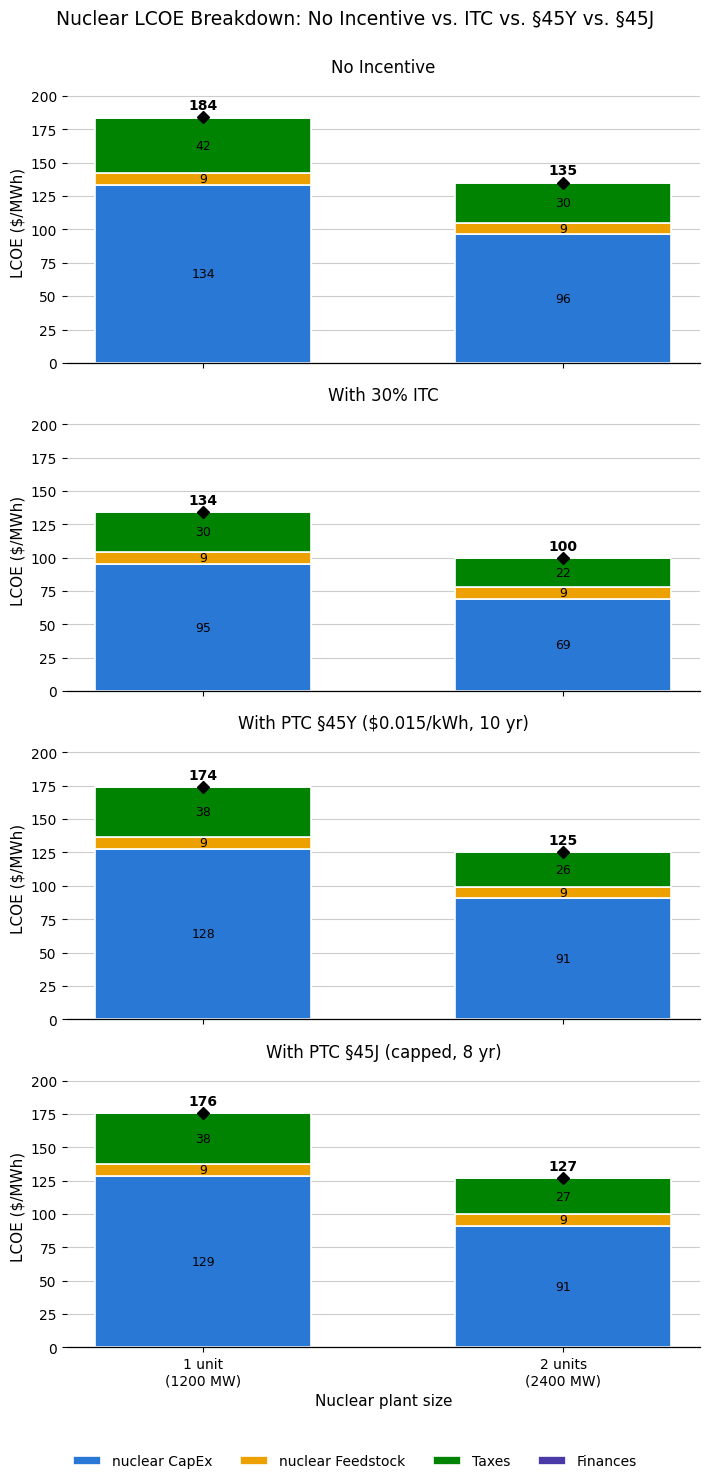

In [3]:
# Defined locally (not reused from itc_plot's globals) so this cell doesn't
# break if it runs after another cell that reassigns `colors`, `categories`,
# etc. to something else (e.g. dc_cost_plot defines its own `colors` dict).
categories = ["nuclear CapEx", "nuclear Feedstock", "Taxes", "Finances"]
colors = {
    "nuclear CapEx": "#2a78d6",      # slot 1 blue
    "nuclear Feedstock": "#eda100",  # slot 3 yellow
    "Taxes": "#008300",              # slot 4 green
    "Finances": "#4a3aa7",           # slot 5 violet
}
ink = "#000000"
grid_color = "#cccccc"
LABEL_THRESHOLD = 0.04

fig, axes = plt.subplots(4, 1, figsize=(7.2, 14.5), sharex=True)

sizes = df_no_incentive.index.values.astype(float)
x = np.arange(len(sizes))
bar_w = 0.6

y_max = max(
    df_no_incentive[categories].sum(axis=1).max(),
    df_itc_breakdown[categories].sum(axis=1).max(),
    df_45y_breakdown[categories].sum(axis=1).max(),
    df_45j_breakdown[categories].sum(axis=1).max(),
)

for ax, df, title in (
    (axes[0], df_no_incentive, "No Incentive"),
    (axes[1], df_itc_breakdown, "With 30% ITC"),
    (axes[2], df_45y_breakdown, "With PTC §45Y ($0.015/kWh, 10 yr)"),
    (axes[3], df_45j_breakdown, "With PTC §45J (capped, 8 yr)"),
):
    bottom = np.zeros(len(sizes))
    for cat in categories:
        vals = df[cat].values.astype(float)
        ax.bar(
            x, vals, bar_w, bottom=bottom, color=colors[cat],
            edgecolor="white", linewidth=1.2, label=cat,
        )
        for xi, (v, b) in enumerate(zip(vals, bottom)):
            mid = b + v / 2
            if v >= y_max * LABEL_THRESHOLD:
                ax.text(
                    x[xi], mid, f"{v:.0f}", ha="center", va="center",
                    fontsize=9, color=ink,
                )
        bottom += vals

    totals = df[categories].sum(axis=1).values
    ax.plot(x, totals, "D", color=ink, ms=6, zorder=5)
    for xi, t in enumerate(totals):
        ax.text(x[xi], t + y_max * 0.02, f"{t:.0f}", ha="center", va="bottom",
                 fontsize=10, color=ink, fontweight="bold")

    ax.set_xticks(x)
    unit_mw = sizes[0]  # smallest size = 1 unit, assumes an N*unit_mw sweep
    ax.set_xticklabels(
        [f"{int(round(s / unit_mw))} unit{'s' if s > unit_mw else ''}\n({int(s)} MW)" for s in sizes]
    )
    ax.set_title(title, fontsize=12, color=ink)
    ax.set_ylim(0, y_max * 1.15)
    ax.grid(axis="y", color=grid_color, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(ink)
    ax.spines["bottom"].set_linewidth(0.9)
    ax.tick_params(colors=ink, labelsize=10)
    ax.set_ylabel("LCOE ($/MWh)", fontsize=11, color=ink)

for a in axes[:-1]:
    a.tick_params(labelbottom=False)
axes[-1].set_xlabel("Nuclear plant size", fontsize=11, color=ink)

handles, plabels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, plabels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.015),
    frameon=False, fontsize=10, labelcolor=ink,
)
fig.suptitle("Nuclear LCOE Breakdown: No Incentive vs. ITC vs. §45Y vs. §45J",
             fontsize=13.5, color=ink, y=1.0)

fig.tight_layout(rect=[0, 0.025, 1, 1])

out_path = EXAMPLE_DIR / "lcoe_breakdown_3way_comparison.pdf"
fig.savefig(out_path, bbox_inches="tight", transparent=True)
print(f"Saved: {out_path.resolve()}")
plt.show()


## NPV vs. Sell Price: No Incentive vs. ITC vs. §45Y PTC vs. §45J PTC — 1 vs. 2 Units

Same four incentive scenarios as the LCOE breakdown above, now as NPV vs.
sell price sweeps, one panel per unit count (1 unit / 1200 MW, 2 units / 2400
MW), each with a break-even sell price marked per scenario. Reuses
`make_h2i`, `set_itc_all`, `run_at_capacity`, `ITC_FRACTION`,
`get_lco_component`'s sibling for NPV below, `PTC_45Y_CONFIG`, and
`PTC_45J_CONFIG` from the cells above.


In [4]:
def get_npv_component(model):
    for subsys in model.model.system_iter(include_self=True, recurse=True):
        if type(subsys).__name__ == "ProFastNPV":
            return subsys
    raise RuntimeError("ProFastNPV component not found in model tree")


UNIT_MW_NPV = 1200
npv_capacities_mw = [UNIT_MW_NPV * 1, UNIT_MW_NPV * 2]
npv_sell_prices_mwh = [60, 70, 80, 90, 100, 110, 120, 130, 140, 150]

npv_3way_rows = []
for capacity_mw in npv_capacities_mw:
    capacity_kw = capacity_mw * 1000

    # No incentive -- also gives us CapEx to size the ITC credit
    m_base = make_h2i(set_itc_all(base_plant_config, 0.0))
    run_at_capacity(m_base, capacity_kw)
    capex_usd = float(m_base.prob.get_val("nuclear.CapEx", units="USD")[0])

    # ITC, sized to this capacity's own CapEx (applied to both LCOE and NPV blocks)
    itc_usd = ITC_FRACTION * capex_usd
    m_itc = make_h2i(set_itc_all(base_plant_config, itc_usd))
    run_at_capacity(m_itc, capacity_kw)

    # §45Y PTC -- same monkeypatched mechanism as the LCOE cells above, applied
    # to the NPV finance component this time
    m_45y = make_h2i(set_itc_all(base_plant_config, 0.0))
    get_npv_component(m_45y)._ptc_config = PTC_45Y_CONFIG
    run_at_capacity(m_45y, capacity_kw)

    # §45J PTC -- capped rate depends on this capacity (see get_45j_config in ptc_sweep)
    m_45j = make_h2i(set_itc_all(base_plant_config, 0.0))
    get_npv_component(m_45j)._ptc_config = get_45j_config(capacity_kw)
    run_at_capacity(m_45j, capacity_kw)

    for sp_mwh in npv_sell_prices_mwh:
        sp_kwh = sp_mwh / 1000
        row = {"nuclear_mw": capacity_mw, "sell_price_mwh": sp_mwh}
        for label, model in (
            ("no_incentive", m_base), ("itc", m_itc), ("45y", m_45y), ("45j", m_45j),
        ):
            model.prob.set_val(
                "finance_subgroup_nuclear_npv.sell_price_electricity", sp_kwh, units="USD/(kW*h)"
            )
            model.run()
            row[f"npv_{label}_b"] = (
                float(
                    model.prob.get_val("finance_subgroup_nuclear_npv.NPV_electricity", "USD")[0]
                )
                / 1e9
            )
        npv_3way_rows.append(row)

df_npv_3way = pd.DataFrame(npv_3way_rows)
print(df_npv_3way.to_string(index=False))


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


...

/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


 nuclear_mw  sell_price_mwh  npv_no_incentive_b  npv_itc_b  npv_45y_b  npv_45j_b
       1200              60           -4.905925  -2.939068  -4.513244  -4.574198
       1200              70           -4.510339  -2.543481  -4.117657  -4.178612
       1200              80           -4.114752  -2.147895  -3.722071  -3.783025
       1200              90           -3.719166  -1.752308  -3.326484  -3.387438
       1200             100           -3.323579  -1.356722  -2.930898  -2.991852
       1200             110           -2.927993  -0.961135  -2.535311  -2.596265
       1200             120           -2.532406  -0.565549  -2.139725  -2.200679
       1200             130           -2.136820  -0.169962  -1.744138  -1.805092
       1200             140           -1.741233   0.225624  -1.348552  -1.409506
       1200             150           -1.345647   0.621211  -0.952965  -1.013919
       2400              60           -5.948425  -3.166868  -5.163062  -5.284970
       2400              70 

Saved: /Users/svijaysh/NPP+DCfork/H2Integrate/examples/32_nuclear_DC_case_1/npv_incentive_comparison_.pdf


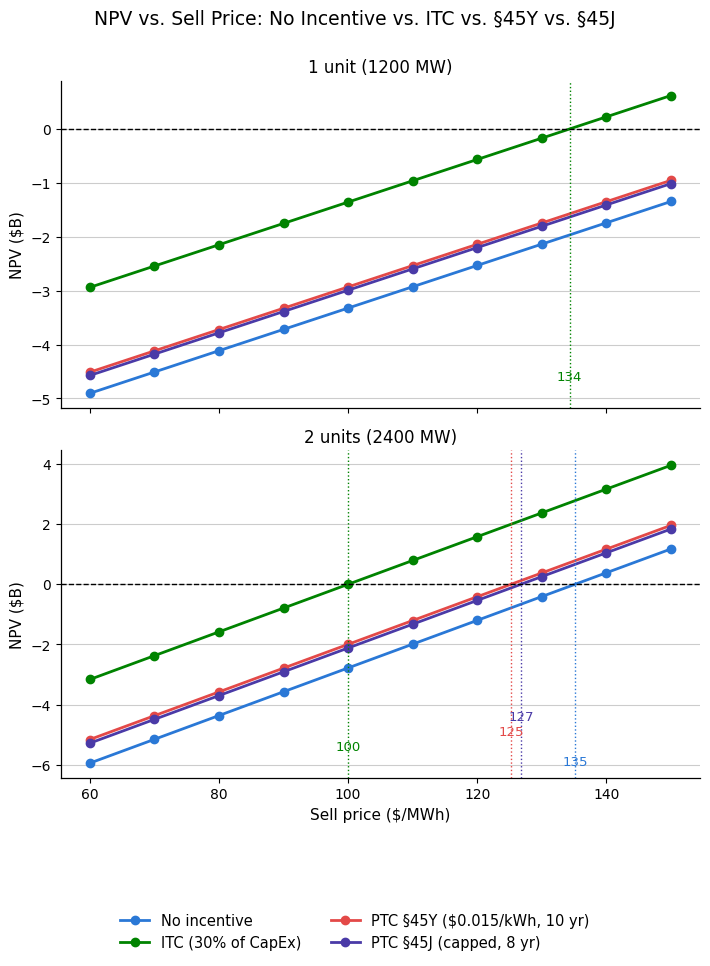

In [5]:
ink = "#000000"
grid_color = "#cccccc"

series = (
    ("npv_no_incentive_b", "#2a78d6", "No incentive"),
    ("npv_itc_b", "#008300", "ITC (30% of CapEx)"),
    ("npv_45y_b", "#e34948", "PTC §45Y ($0.015/kWh, 10 yr)"),
    ("npv_45j_b", "#4a3aa7", "PTC §45J (capped, 8 yr)"),
)

fig, axes = plt.subplots(2, 1, figsize=(7.2, 9.0), sharex=True)

for ax, capacity_mw in zip(axes, npv_capacities_mw):
    sub = df_npv_3way[df_npv_3way["nuclear_mw"] == capacity_mw]
    n_units = round(capacity_mw / UNIT_MW_NPV)

    for col, color, label in series:
        ax.plot(sub["sell_price_mwh"], sub[col], "-o", color=color, ms=6, linewidth=2, label=label)

    ax.axhline(0, color=ink, lw=1.0, ls="--")

    for series_idx, (col, color, label) in enumerate(series):
        y = sub[col].values
        xv = sub["sell_price_mwh"].values
        sign_change = np.where(np.diff(np.sign(y)))[0]
        if len(sign_change):
            i = sign_change[0]
            x0, x1 = xv[i], xv[i + 1]
            y0, y1 = y[i], y[i + 1]
            breakeven = x0 + (0 - y0) * (x1 - x0) / (y1 - y0)
            ax.axvline(breakeven, color=color, lw=1.0, ls=":")
            # Stack labels vertically by series so near-identical breakevens
            # (e.g. the two PTCs) don't render on top ofw each other.
            y_lo, y_hi = ax.get_ylim()
            label_y = y_lo + (y_hi - y_lo) * (0.04 + 0.045 * series_idx)
            ax.text(
                breakeven, label_y,
                f"{breakeven:.0f}", color=color, fontsize=9.5, ha="center",
            )

    ax.set_title(f"{n_units} unit{'s' if n_units > 1 else ''} ({int(capacity_mw)} MW)",
                 fontsize=12, color=ink)
    ax.set_ylabel("NPV ($B)", fontsize=11, color=ink)
    ax.grid(axis="y", color=grid_color, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(ink)
    ax.spines["left"].set_color(ink)
    ax.spines["bottom"].set_linewidth(0.9)
    ax.spines["left"].set_linewidth(0.9)
    ax.tick_params(colors=ink, labelsize=10)

axes[1].set_xlabel("Sell price ($/MWh)", fontsize=11, color=ink)

handles, plabels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, plabels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.06),
    frameon=False, fontsize=10.5, labelcolor=ink,
)
fig.suptitle("NPV vs. Sell Price: No Incentive vs. ITC vs. §45Y vs. §45J",
             fontsize=13.5, color=ink, y=1.0)
fig.tight_layout(rect=[0, 0.08, 1, 1])

out_path = EXAMPLE_DIR / "npv_incentive_comparison_.pdf"
fig.savefig(out_path, bbox_inches="tight", transparent=True)
print(f"Saved: {out_path.resolve()}")
plt.show()
